# Preprocesado del dataset

Aplicamos las decisiones que tomamos en el EDA para transformar los datos crudos en datos listos para el modelo.

Pasos:
1. Cargar train y test (ya separados desde el split estratificado).
2. Eliminar `Net Income Flag` (feature constante detectada en EDA).
3. Escalar con `QuantileTransformer` (ajustado solo con train).
4. Reducir dimensiones con PCA (ajustado solo con train).
5. Guardar los datasets preprocesados y los transformadores ajustados.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
import joblib

pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)

## 1. Cargar los datos del split estratificado

In [2]:
train = pd.read_csv('../split-dataset/train/train-data.csv')
test = pd.read_csv('../split-dataset/test/test-data.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')

Train: (5455, 96)
Test:  (1364, 96)


## 2. Eliminar feature constante

En el EDA detectamos que `Net Income Flag` tiene un único valor para todas las empresas, no aporta nada al modelo.

In [3]:
TARGET = 'Bankrupt?'

# El nombre original en el CSV viene con espacio al inicio en muchas columnas.
# Buscamos la columna constante por substring para que no falle si cambia el formato.
col_constante = [c for c in train.columns if c.strip() == 'Net Income Flag'][0]

train = train.drop(columns=[col_constante])
test = test.drop(columns=[col_constante])

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')
print(f'Features restantes: {X_train.shape[1]}')

X_train: (5455, 94), y_train: (5455,)
X_test:  (1364, 94), y_test:  (1364,)
Features restantes: 94


## 3. Escalado con QuantileTransformer

In [4]:
scaler = QuantileTransformer(output_distribution='normal', random_state=42)

# fit_transform en train (aprende los percentiles del train)
X_train_scaled = scaler.fit_transform(X_train)
# transform en test (usa los mismos percentiles aprendidos del train)
X_test_scaled = scaler.transform(X_test)

# Convertimos de vuelta a DataFrame para inspección
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Comparación antes/después en algunas features representativas
muestras_keywords = ['Quick Ratio', 'Total Asset Growth Rate', 'ROA(A)', 'Debt ratio %']
muestras_cols = [c for c in X_train.columns if any(k in c for k in muestras_keywords)]

print('Antes del escalado (algunas features representativas):')
print(X_train[muestras_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))
print('\nDespués del escalado:')
print(X_train_scaled[muestras_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

Antes del escalado (algunas features representativas):
      ROA(A) before interest and % after tax  Total Asset Growth Rate   Quick Ratio  Debt ratio %
mean                                    0.56             5.509706e+09  8.196150e+06          0.11
std                                     0.07             2.888785e+09  2.409200e+08          0.05
min                                     0.00             0.000000e+00  0.000000e+00          0.00
max                                     1.00             9.980000e+09  9.230000e+09          1.00

Después del escalado:
      ROA(A) before interest and % after tax  Total Asset Growth Rate  Quick Ratio  Debt ratio %
mean                                     0.0                     0.00          0.0          -0.0
std                                      1.0                     1.01          1.0           1.0
min                                     -5.2                    -5.20         -5.2          -5.2
max                                      5.2

## 4. Reducción de dimensiones con PCA

Por la multicolinealidad fuerte que vimos en el EDA (36 pares con |corr| > 0.9), aplicamos PCA para reducir las features a un número menor de componentes ortogonales.

Usamos `n_components=0.95`, que le pide a PCA quedarse con los componentes necesarios para conservar el 95% de la varianza total.

Componentes seleccionados: 31
Varianza explicada total: 0.9514
Shape final - train: (5455, 31), test: (1364, 31)


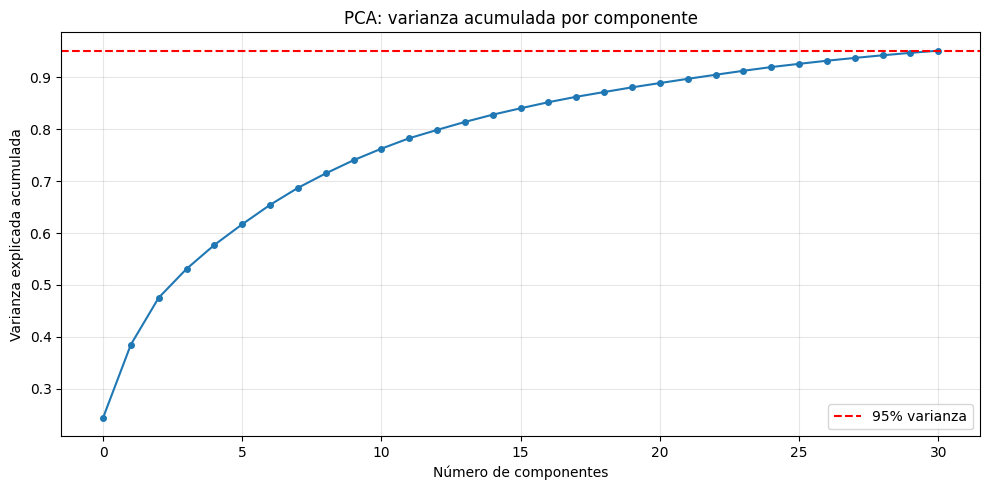

In [5]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Componentes seleccionados: {pca.n_components_}')
print(f'Varianza explicada total: {pca.explained_variance_ratio_.sum():.4f}')
print(f'Shape final - train: {X_train_pca.shape}, test: {X_test_pca.shape}')

# Plot de varianza explicada acumulada
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', markersize=4)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA: varianza acumulada por componente')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Guardar los datasets preprocesados y los transformadores

Guardamos los datasets preprocesados (train y test) en `split-dataset/preprocessed/`

Los transformadores ajustados (scaler y pca) en `split-dataset/preprocessed/` para poder aplicarlos a futuros datos sin re-ajustar.

In [6]:
OUTPUT_DIR = Path('../split-dataset/preprocessed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pc_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
train_out = pd.DataFrame(X_train_pca, columns=pc_cols)
train_out[TARGET] = y_train.values

test_out = pd.DataFrame(X_test_pca, columns=pc_cols)
test_out[TARGET] = y_test.values

train_out.to_csv(OUTPUT_DIR / 'train.csv', index=False)
test_out.to_csv(OUTPUT_DIR / 'test.csv', index=False)

joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
joblib.dump(pca, OUTPUT_DIR / 'pca.pkl')

print(f'Datasets preprocesados guardados en {OUTPUT_DIR}/')
print(f'  - train.csv: {train_out.shape}')
print(f'  - test.csv:  {test_out.shape}')
print('Transformadores guardados:')
print('  - scaler.pkl')
print('  - pca.pkl')

Datasets preprocesados guardados en ..\split-dataset\preprocessed/
  - train.csv: (5455, 32)
  - test.csv:  (1364, 32)
Transformadores guardados:
  - scaler.pkl
  - pca.pkl
